# 02 — Risk Prioritization (Fase 3B)

**Priority Score 0-100** = `100·Σ w_k·c_k` combinando riesgo actual (0.35), evolución/CES (0.25), eventos (0.15), comorbilidades (0.15) y adherencia (0.10). Bandas: Baja / Media / Alta / Crítica.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


In [2]:
pr = pd.read_csv(MET/'priority.csv')
print(pr.priority_band.value_counts().reindex(['Crítica','Alta','Media','Baja']))
pr.groupby('archetype').priority_score.mean().round(1).sort_values(ascending=False)

priority_band
Crítica     46
Alta       150
Media       47
Baja       157
Name: count, dtype: int64


archetype
Alto riesgo persistente    73.6
Deterioro lento            67.7
Oscilante                  56.7
Estable                    22.7
Mejora rápida              12.5
Name: priority_score, dtype: float64

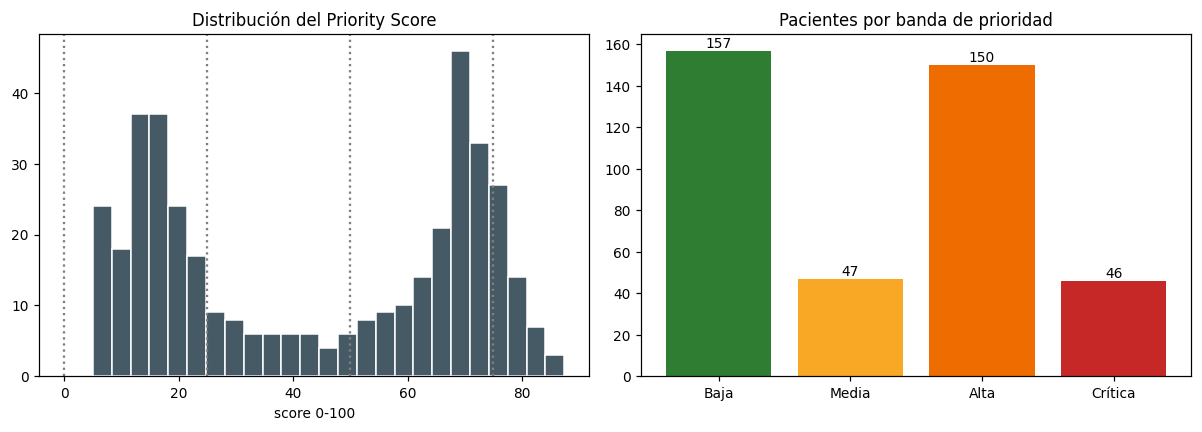

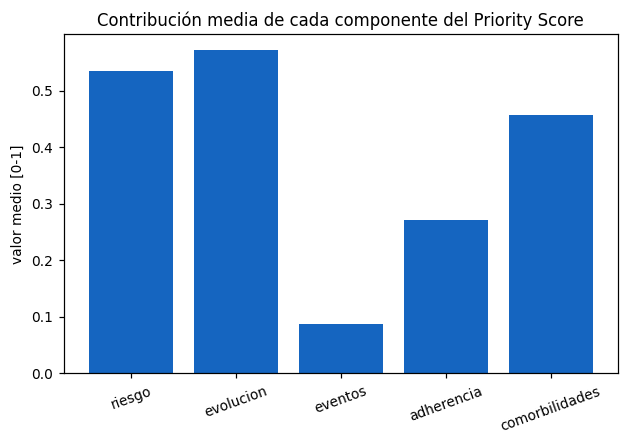

In [3]:
show(FIG/'priority'/'priority_distribution.png')
show(FIG/'priority'/'priority_components.png')

### Conclusión 3B
El Priority Score ordena a los pacientes por necesidad de atención y es **monótono con el riesgo** (validado en NB 07). El driver dominante suele ser el riesgo actual y la evolución.